# Updatining Predictions for Unlabeled Trials

##### Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import deeplabcut
import DLCsupport as dlcs
import deeplabcut as dlc
import matplotlib.pyplot as plt
from importlib.util import spec_from_file_location, module_from_spec
import glob
import xrommtools_copy as xt
import re
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

from PIL import Image
from PostAnalysis_review import find_darkest_pixel, collect_images, _correct_camera_frame, _extract_camera_predictions, find_dark_blob_centroid



module_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\data-converters.py"
spec = spec_from_file_location("dc", module_path)
dc = module_from_spec(spec)
spec.loader.exec_module(dc)

module_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools_copy.py"
spec = spec_from_file_location("xt", module_path)
xt = module_from_spec(spec)
spec.loader.exec_module(xt)

Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


##### Padding data to keep length

In [3]:

def pad_df_to_trial_length(df, total_frames, start_frame):
    """
    Pad a dataframe with NaN rows so that its rows correspond to
    frames start_frame ... start_frame + len(df) - 1.

    Parameters
    ----------
    df : pd.DataFrame
        Predicted subset.
    total_frames : int
        Total number of frames in the trial.
    start_frame : int
        Original frame number of df.iloc[0].
    """
    full_df = pd.DataFrame(
        np.nan,
        index=range(total_frames),
        columns=df.columns,
    )

    full_df.iloc[start_frame:start_frame + len(df)] = df.to_numpy()

    return full_df

##### Snapping to Dark Pixel (FXN)

In [4]:

def snap_combined_predictions_to_dark_pixels(
    pred_csv,
    cam1_dir,
    cam2_dir,
    out_csv=None,
    window_size=5,
    # Trial_frames : int = 6000
):
    """Snap each predicted keypoint to the nearest dark pixel in the matching frame image."""
    pred_csv = Path(pred_csv)
    cam1_dir = Path(cam1_dir)
    cam2_dir = Path(cam2_dir)

    df = pd.read_csv(pred_csv)
    out = df.copy()

    images_by_cam = {
        "cam1": collect_images(cam1_dir),
        "cam2": collect_images(cam2_dir),
    }

    # Parse columns like bodypart_cam1_X / bodypart_cam2_Y
    col_pattern = re.compile(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$")
    col_map = {}
    bodyparts = set()
    for col in out.columns:
        match = col_pattern.match(str(col))
        if match is None:
            continue
        bp = str(match.group("bodypart"))
        cam = f"cam{match.group('cam')}"
        coord = str(match.group("coord")).upper()
        col_map[(bp, cam, coord)] = col
        bodyparts.add(bp)

    if not bodyparts:
        raise ValueError(
            "No prediction columns found in combined format (expected bodypart_cam1_X style columns)."
        )

    bodyparts = sorted(bodyparts)

    n_frames = len(out)
    print(f"Snapping {len(bodyparts)} bodyparts across {n_frames} frames...")

    for frame_pos in range(n_frames):
        if frame_pos % 100 == 0:
            print(f"  frame {frame_pos}/{n_frames - 1}")

        for cam in ("cam1", "cam2"):
            images = images_by_cam[cam]
            if not (0 <= frame_pos < len(images)):
                continue

            with Image.open(images[frame_pos]) as image_file:
                gray_img = np.asarray(image_file.convert("L"))

            occupied_pixels = set()

            for bp in bodyparts:
                xcol = col_map.get((bp, cam, "X"))
                ycol = col_map.get((bp, cam, "Y"))
                if xcol is None or ycol is None:
                    continue

                x_val = pd.to_numeric(out.at[frame_pos, xcol], errors="coerce")
                y_val = pd.to_numeric(out.at[frame_pos, ycol], errors="coerce")
                if not (np.isfinite(x_val) and np.isfinite(y_val)):
                    continue

                rr, cc = find_darkest_pixel(
                    gray_img,
                    row=float(y_val),
                    col=float(x_val),
                    occupied=occupied_pixels,
                    window_size=int(window_size),
                )

                out.at[frame_pos, xcol] = float(cc)
                out.at[frame_pos, ycol] = float(rr)

    if out_csv is None:
        out_csv = pred_csv.with_name(f"{pred_csv.stem}_snapped_dark.csv")
    else:
        out_csv = Path(out_csv)
    
    # pad_df_to_trial_length(out, Trial_frames, start_frame)

    out.to_csv(out_csv, index=False)
    print(f"Saved snapped predictions: {out_csv}")
    return out_csv, out


# snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
#     pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints.csv",
#     cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
#     cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
#     # out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
#     window_size=4,
# )

# snapped_df.head()

##### Correcting Using the Blob Magnet (FXN)

In [5]:
from pathlib import Path
import pandas as pd
import time
import cv2


def correct_frames_from_trial_dir(
    trial_dir: Path,
    frames_to_correct,
    max_match_dist: float = 15.0,
    pred_csv_pattern: str = "*Predicted2DPoints*.csv",
    cam_names=("Cam1", "Cam2"),
    image_collector=None,
    correction_fn=None,
    output_suffix: str = "df_corrected.csv",
    verbose: bool = True,
):
    """
    Run correction pipeline using a single experiment/trial directory.

    Expected structure:
        trial_dir/
            pred_csv_name
            Cam1/
            Cam2/
    """

    trial_dir = Path(trial_dir)

    if image_collector is None:
        raise ValueError("image_collector must be provided")

    if correction_fn is None:
        raise ValueError("correction_fn must be provided")

    # ----------------------------
    # Resolve paths automatically
    # ----------------------------
    matches = sorted(trial_dir.glob(pred_csv_pattern))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No CSV matching '{pred_csv_pattern}' found in {trial_dir}"
        )
    elif len(matches) > 1:
        raise FileExistsError(
            "Multiple matching CSVs found:\n"
            + "\n".join(str(p.name) for p in matches)
        )

    pred_csv = matches[0]


    cam_dirs = {
        cam: trial_dir / cam
        for cam in cam_names
    }

    out_csv = trial_dir / output_suffix

    # ----------------------------
    # Load data
    # ----------------------------
    df = pd.read_csv(pred_csv)
    df_corrected = df.copy(deep=True)

    # ----------------------------
    # Load images
    # ----------------------------
    image_paths = {
        cam: image_collector(folder)
        for cam, folder in cam_dirs.items()
    }

    cams = list(image_paths.keys())

    if len(cams) >= 2:
        n0 = len(image_paths[cams[0]])
        for c in cams[1:]:
            if len(image_paths[c]) != n0:
                print(
                    f"Cam mismatch: {cams[0]}={n0}, {c}={len(image_paths[c])}"
                )

    # ----------------------------
    # Validate frames
    # ----------------------------
    frames_to_correct = sorted(set(int(x) for x in frames_to_correct))

    valid_frames = [
        i for i in frames_to_correct
        if 0 <= i < len(df_corrected)
        and all(i < len(image_paths[c]) for c in cams)
    ]

    if not valid_frames:
        raise ValueError("No valid frames after filtering.")

    # ----------------------------
    # Processing
    # ----------------------------
    t0 = time.perf_counter()

    for n, frame_idx in enumerate(valid_frames, start=1):

        row = df_corrected.iloc[frame_idx]

        for camera in cams:

            img_path = image_paths[camera][frame_idx]

            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue

            updates = correction_fn(
                image=gray,
                row=row,
                camera=camera.lower(),
                max_match_dist=max_match_dist,
            )

            if updates:
                df_corrected.loc[
                    df_corrected.index[frame_idx],
                    list(updates.keys())
                ] = list(updates.values())

        if verbose and (n % 250 == 0 or n == len(valid_frames)):
            print(f"Corrected {n}/{len(valid_frames)} frames")

    elapsed = time.perf_counter() - t0

    df_corrected.to_csv(out_csv, index=False)

    if verbose:
        print(f"Saved: {out_csv}")
        print(f"Done {len(valid_frames)} frames in {elapsed:.1f}s")

    return df_corrected


# df_out = correct_frames_from_trial_dir(
#     trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8"),
#     frames_to_correct=list(range(1812, 4675)),
#     max_match_dist=15.0,
#     image_collector=collect_images,
#     correction_fn=_correct_camera_frame,
# )

In [6]:

def correct_frames_from_df(
    trial_dir: Path,
    frames_to_correct: tuple[int,int] | list [int],
    pred_df,
    max_match_dist: float = 15.0,
    cam_names=("Cam1", "Cam2"),
    image_collector=None,
    correction_fn=None,
    output_suffix: str = "df_corrected.csv",
    verbose: bool = True,
):
    """
    Run correction pipeline using a single experiment/trial directory.

    Expected structure:
        trial_dir/
            pred_csv_name
            Cam1/
            Cam2/
    """

    trial_dir = Path(trial_dir)

    if image_collector is None:
        raise ValueError("image_collector must be provided")

    if correction_fn is None:
        raise ValueError("correction_fn must be provided")

    cam_dirs = {
        cam: trial_dir / cam
        for cam in cam_names
    }

    df_corrected = pred_df.copy(deep=True)

    # ----------------------------
    # Load images
    # ----------------------------
    image_paths = {
        cam: image_collector(folder)
        for cam, folder in cam_dirs.items()
    }

    cams = list(image_paths.keys())

    if len(cams) >= 2:
        n0 = len(image_paths[cams[0]])
        for c in cams[1:]:
            if len(image_paths[c]) != n0:
                print(
                    f"Cam mismatch: {cams[0]}={n0}, {c}={len(image_paths[c])}"
                )

    # ----------------------------
    # Validate frames
    # ----------------------------
    frames_to_correct = sorted(set(int(x) for x in frames_to_correct))

    valid_frames = [
        i for i in frames_to_correct
        if 0 <= i < len(df_corrected)
        and all(i < len(image_paths[c]) for c in cams)
    ]

    if not valid_frames:
        raise ValueError("No valid frames after filtering.")

    # ----------------------------
    # Processing
    # ----------------------------
    t0 = time.perf_counter()

    for n, frame_idx in enumerate(valid_frames, start=1):

        row = df_corrected.iloc[frame_idx]

        for camera in cams:

            img_path = image_paths[camera][frame_idx]

            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue

            updates = correction_fn(
                image=gray,
                row=row,
                camera=camera.lower(),
                max_match_dist=max_match_dist,
            )

            if updates:
                df_corrected.loc[
                    df_corrected.index[frame_idx],
                    list(updates.keys())
                ] = list(updates.values())

        if verbose and (n % 250 == 0 or n == len(valid_frames)):
            print(f"Corrected {n}/{len(valid_frames)} frames")

    elapsed = time.perf_counter() - t0

    if verbose:
        print(f"Done {len(valid_frames)} frames in {elapsed:.1f}s")

    return df_corrected

In [7]:
def correct_frames_from_df_fast(
    trial_dir: Path,
    frames_to_correct: tuple[int,int] | list [int],
    pred_df,
    max_match_dist: float = 15.0,
    cam_names=("Cam1", "Cam2"),
    image_collector=None,
    correction_fn=None,
    output_suffix: str = "df_corrected.csv",
    verbose: bool = True,
):
    """
    Run correction pipeline using a single experiment/trial directory.

    Expected structure:
        trial_dir/
            pred_csv_name
            Cam1/
            Cam2/
    """

    trial_dir = Path(trial_dir)

    if image_collector is None:
        raise ValueError("image_collector must be provided")

    if correction_fn is None:
        raise ValueError("correction_fn must be provided")

    cam_dirs = {
        cam: trial_dir / cam
        for cam in cam_names
    }

    df_corrected = pred_df.copy(deep=True)

    # ----------------------------
    # Load images
    # ----------------------------
    image_paths = {
        cam: image_collector(folder)
        for cam, folder in cam_dirs.items()
    }

    cams = list(image_paths.keys())

    if len(cams) >= 2:
        n0 = len(image_paths[cams[0]])
        for c in cams[1:]:
            if len(image_paths[c]) != n0:
                print(
                    f"Cam mismatch: {cams[0]}={n0}, {c}={len(image_paths[c])}"
                )

    # ----------------------------
    # Validate frames
    # ----------------------------
    frames_to_correct = sorted(set(int(x) for x in frames_to_correct))

    valid_frames = [
        i for i in frames_to_correct
        if 0 <= i < len(df_corrected)
        and all(i < len(image_paths[c]) for c in cams)
    ]

    if not valid_frames:
        raise ValueError("No valid frames after filtering.")

    # ----------------------------
    # Processing
    # ----------------------------
    

    t0 = time.perf_counter()


    def process_frame(frame_idx):
        row = df_corrected.iloc[frame_idx]
        frame_updates = {}

        for camera in cams:
            img_path = image_paths[camera][frame_idx]

            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue

            updates = correction_fn(
                image=gray,
                row=row,
                camera=camera.lower(),
                max_match_dist=max_match_dist,
            )

            if updates:
                frame_updates.update(updates)

        return frame_idx, frame_updates

    # This is super important for the Parallelization of this timely task
    with ThreadPoolExecutor() as executor:
        futures = {
            executor.submit(process_frame, frame_idx): frame_idx
            for frame_idx in valid_frames
        }

        for n, future in enumerate(as_completed(futures), start=1):
            frame_idx, updates = future.result()

            if updates:
                df_corrected.loc[
                    df_corrected.index[frame_idx],
                    list(updates.keys())
                ] = list(updates.values())

            if verbose and (n % 250 == 0 or n == len(valid_frames)):
                print(f"Corrected {n}/{len(valid_frames)} frames")

    elapsed = time.perf_counter() - t0

    if verbose:
        print(f"Done {len(valid_frames)} frames in {elapsed:.1f}s")

    return df_corrected

##### Predict with a folder containing JPG stacks (FXN):
file structure: (ProcessingData/Bird/Trialnum)

In [8]:
def predict_trial_from_jpg_stacks(
    config_path: str | Path,
    bird : str,
    trial_number : int | str,
    base_processing_dir : Path = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps : int = 500,
    batchsize : int = 16,
    save_as_csv : bool = True,
    xma_base_name : str = "ModelUpdateCorrected",
    snap_window_size :int = 4,
    frame_range: list[int] | tuple[int, int] | None = None,
):
    """
    End-to-end trial prediction pipeline:
    1) Convert Cam1/Cam2 JPG stacks to AVI
    2) Run DLC prediction from config.yaml
    3) Convert DLC CSV outputs to XMA combined 2D points CSV
    4) Snap combined predictions to nearest dark pixels

    Parameters
    ----------
    config_path : str or Path
        Path to a DeepLabCut config.yaml file.
    bird : str
        Bird folder name under ProcessingData (e.g., "Tulio", "DavidBowie").
    trial_number : int or str
        Trial number used to build Trial{n} (e.g., 1 -> Trial1).
    base_processing_dir : Path
        Root folder containing bird trial data.
    fps : int
        FPS used to build AVI files from JPG stacks.
    batchsize : int
        Batch size used by dlc.analyze_videos.
    save_as_csv : bool
        Whether to save predictions as CSV.
    xma_base_name : str
        Prefix used by xt.dlc_to_xma for output naming.
    snap_window_size : int
        Search window size used when snapping to dark pixels.
    """
    config_path = Path(config_path)
    trial_dir = Path(base_processing_dir) / str(bird) / f"Trial{trial_number}"

    cam1_dir = trial_dir / "Cam1"
    cam2_dir = trial_dir / "Cam2"
    cam1_avi = trial_dir / "Cam1.avi"
    cam2_avi = trial_dir / "Cam2.avi"
    total_frames = len(list(cam1_dir.glob("*.jpg")))

    if not cam1_dir.exists() or not cam2_dir.exists():
        raise FileNotFoundError(
            f"Expected Cam1/Cam2 folders in {trial_dir}, but one or both are missing."
        )
    
    # 1) Build videos from image stacks
    if frame_range is None:
        start_frame = None
        end_frame = None
    else:
        start_frame, end_frame = map(int, frame_range)
    if not cam1_avi.exists() and not cam2_avi.exists():
        print("Converting Cine Image stacks to AVI videos")
        dc.jpg_stack_to_avi(input_folder=cam1_dir, output_path=cam1_avi, fps=int(fps), start_frame = start_frame, end_frame = end_frame)
        dc.jpg_stack_to_avi(input_folder=cam2_dir, output_path=cam2_avi, fps=int(fps), start_frame = start_frame, end_frame = end_frame)
    else:
        print("Cine Image Conversions Found")
    print("Now To Analyze the videos with existing model!")


    # Check if DLC file exists
    if not sorted(
        trial_dir.glob("Cam1DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    ):
        
        # 2) Run prediction using the provided DLC config
        dlc.analyze_videos(
            str(config_path),
            [str(cam1_avi), str(cam2_avi)],
            save_as_csv=bool(save_as_csv),
            destfolder=str(trial_dir),
            batchsize=int(batchsize),
        )

    # 3) Find newest DLC CSV outputs and convert to XMA combined format
    cam1_candidates = sorted(
        trial_dir.glob("Cam1DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    cam2_candidates = sorted(
        trial_dir.glob("Cam2DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    print(cam1_candidates)

    if not cam1_candidates or not cam2_candidates:
        raise FileNotFoundError(
            f"Could not find Cam1DLC*.csv / Cam2DLC*.csv in {trial_dir} after prediction."
        )

    cam1_dlc_csv = cam1_candidates[-1]
    cam2_dlc_csv = cam2_candidates[-1]
    print("Converting predictions to XMA format")
    pred_df = xt.dlc_to_xma(
        str(cam1_dlc_csv),
        str(cam2_dlc_csv),
        str(xma_base_name),
        str(trial_dir),
    )

    
    # padding NaN on our data so it matches full video length
    nan_padded_df = pad_df_to_trial_length(pred_df, total_frames = total_frames, start_frame = start_frame)

    corrected_df = correct_frames_from_df_fast(
        trial_dir=trial_dir,
        pred_df = nan_padded_df,
        frames_to_correct=list(range(start_frame, end_frame)),
        max_match_dist=15.0,
        image_collector=collect_images,
        correction_fn=_correct_camera_frame,
    )

    # 4) Snap the generated combined predictions to dark pixels
    pred_csv = trial_dir / f"{xma_base_name}-Predicted2DPoints.csv"
    corrected_df.to_csv(pred_csv, na_rep='NaN',index=False)

    print(f"Finished full pipeline for {bird} Trial{trial_number} -> {trial_dir}")
    return {
        "trial_dir": trial_dir,
        "cam1_avi": cam1_avi,
        "cam2_avi": cam2_avi,
        "cam1_dlc_csv": cam1_dlc_csv,
        "cam2_dlc_csv": cam2_dlc_csv,
        "pred_csv": pred_csv,
        # "snapped_csv": Path(snapped_csv),
        # "snapped_df": snapped_df,
    }


# Example usage (Trial 1)
# result = predict_trial_from_jpg_stacks(
#     config_path=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml",
#     bird="Tulio",
#     trial_number=1,
#     frame_range = [1200,2400]

# )

#####  Active Update Helpers (FXN)

In [9]:
from pathlib import Path
import glob
import shutil
import re
import time
import pandas as pd


# Create the Active Updates Base Paths
def _active_update_roots(
    base_dir: str | Path,
    bird: str,
    trial_num: int,
) -> list[Path]:
    base_dir = Path(base_dir)
    return [
        # base_dir / bird / "ActiveUpdates" / f"Trial{trial_num}",
        base_dir / bird / f"Trial{trial_num}" / "active_updates",
    ]

# Identify the Active Updates Paths
def _list_active_update_dirs(
    base_dir: str | Path,
    bird: str,
    trial_num: int,
) -> list[Path]:
    active_dirs: list[Path] = []
    seen: set[str] = set()

    for root in _active_update_roots(base_dir, bird, trial_num):
        if not root.exists():
            continue

        for path in sorted(p for p in root.iterdir() if p.is_dir()):
            resolved = str(path.resolve()).lower()
            if resolved in seen:
                continue
            seen.add(resolved)
            active_dirs.append(path)

    return active_dirs


def _resolve_active_update_dir(
    base_dir: str | Path,
    bird: str,
    trial_num: int,
    update_set: str | None = None,
) -> Path:
    active_dirs = _list_active_update_dirs(base_dir, bird, trial_num)

    if len(active_dirs) == 0:
        searched = "\n".join(str(path) for path in _active_update_roots(base_dir, bird, trial_num))
        raise FileNotFoundError(
            "No active update folders found. Checked:\n"
            f"{searched}"
        )

    if update_set is not None:
        matches = [path for path in active_dirs if path.name.lower() == update_set.lower()]
        if len(matches) == 0:
            options = ", ".join(path.name for path in active_dirs)
            raise FileNotFoundError(
                f"Update set '{update_set}' not found for {bird} Trial{trial_num}. "
                f"Available: {options}"
            )
        return matches[0]

    if len(active_dirs) == 1:
        return active_dirs[0]

    unified_matches = [path for path in active_dirs if path.name.lower() == "unified"]
    if len(unified_matches) == 1:
        return unified_matches[0]

    options = ", ".join(path.name for path in active_dirs)
    raise ValueError(
        f"Multiple active update folders found for {bird} Trial{trial_num}: {options}. "
        "Pass update_set=... to choose one explicitly."
    )




def _extract_image_index(image_name: str) -> int:
    match = re.search(r"(\d+)(?=\.[^.]+$)", Path(image_name).name)
    if match is None:
        raise ValueError(f"Could not extract image index from '{image_name}'.")
    return int(match.group(1))


def unify_active_update_sets(
    source_root: str | Path,
    update_names: tuple[str, ...] = ("dino", "displacement"),
    unified_name: str = "unified",
    overwrite: bool = True,
) -> Path:
    source_root = Path(source_root)
    unified_dir = source_root / unified_name
    update_dirs = [source_root / name for name in update_names]

    missing = [path for path in update_dirs if not path.exists()]
    if missing:
        missing_text = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(f"Missing active update folders:\n{missing_text}")

    if unified_dir.exists() and overwrite:
        shutil.rmtree(unified_dir)

    for subdir in ("cam1", "cam2", "data"):
        (unified_dir / subdir).mkdir(parents=True, exist_ok=True)

    def copy_image_union(camera_folder: str) -> list[int]:
        indexed_paths: dict[int, Path] = {}

        for update_dir in update_dirs:
            for image_path in sorted(path for path in (update_dir / camera_folder).iterdir() if path.is_file()):
                image_index = _extract_image_index(image_path.name)
                if image_index in indexed_paths:
                    raise ValueError(
                        f"Duplicate {camera_folder} image index {image_index} found while merging into {unified_dir}."
                    )
                indexed_paths[image_index] = image_path

        for image_index, image_path in sorted(indexed_paths.items()):
            shutil.copy2(image_path, unified_dir / camera_folder / image_path.name)

        return sorted(indexed_paths)

    cam1_indices = copy_image_union("cam1")
    cam2_indices = copy_image_union("cam2")

    if cam1_indices != cam2_indices:
        raise ValueError("Cam1 and Cam2 image indices do not match after merging.")

    merged_frames = []
    expected_columns = None

    for source_priority, update_dir in enumerate(update_dirs):
        corrections_csv = update_dir / "data" / "corrections_autosave.csv"
        if not corrections_csv.exists():
            raise FileNotFoundError(f"Missing labels CSV:\n{corrections_csv}")

        df = pd.read_csv(corrections_csv).copy()

        if expected_columns is None:
            expected_columns = list(df.columns)
        elif list(df.columns) != expected_columns:
            raise ValueError(
                f"CSV columns do not match between update sets.\n"
                f"Expected: {expected_columns}\n"
                f"Found: {list(df.columns)}"
            )

        df["_image_index"] = df["image_cam1"].map(_extract_image_index)
        df["_source_priority"] = source_priority

        if df["_image_index"].duplicated().any():
            duplicates = df.loc[df["_image_index"].duplicated(), "_image_index"].tolist()
            raise ValueError(
                f"Duplicate frame indices found within {corrections_csv}: {duplicates[:10]}"
            )

        merged_frames.append(df)

    merged_df = pd.concat(merged_frames, ignore_index=True)
    merged_df = merged_df.sort_values(["_image_index", "_source_priority"], kind="stable")
    merged_df = merged_df.drop_duplicates(subset="_image_index", keep="first")

    merged_indices = merged_df["_image_index"].tolist()
    if merged_indices != cam1_indices:
        raise ValueError(
            "Merged CSV frame order does not match merged image order.\n"
            f"Images: {cam1_indices[:10]} ...\n"
            f"CSV: {merged_indices[:10]} ..."
        )

    if "frame_pos" in merged_df.columns:
        merged_df["frame_pos"] = range(len(merged_df))

    merged_df = merged_df.drop(columns=["_image_index", "_source_priority"])
    merged_df = merged_df[expected_columns]
    merged_df.to_csv(unified_dir / "data" / "corrections_autosave.csv", index=False)

    for update_dir in update_dirs:
        for extra_file in sorted((update_dir / "data").iterdir()):
            if not extra_file.is_file() or extra_file.name == "corrections_autosave.csv":
                continue
            dest_file = unified_dir / "data" / extra_file.name
            if dest_file.exists():
                raise ValueError(f"Duplicate extra data file name while merging: {extra_file.name}")
            shutil.copy2(extra_file, dest_file)

    print(f"Created unified update folder: {unified_dir}")
    print(f"Merged {len(cam1_indices)} frames from: {', '.join(update_names)}")
    return unified_dir


##### Update Training the Model from Snapshot (FXN)

In [ ]:

def train_update_model(
    bird: str,
    trial_num: int,
    snapshot_path: str | Path = None,
    epochs: int = 100,
    nframes: int = 30,
    frame_selection_seed: int = 42,
    task: str = "Canari",
    experimenter: str = "Tyler",
    finetune_experimenter: str = "Tyler_Finetune",
    base_dir: str | Path = (
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning"
        r"\BirdSongs-MNHN\Testing\ProcessingData"
    ),
    update_set: str | None = None,
):
    """
    Create/update a DLC training dataset for a bird trial and train the model.

    Parameters
    ----------
    bird : str
        Bird name (e.g. 'DavidBowie')
    trial_num : int
        Trial number (e.g. 2)
    snapshot_path : str | Path
        Pretrained snapshot to fine-tune from.
    epochs : int
        Number of training epochs.
    nframes : int
        Frames sampled when building the DLC dataset.
    frame_selection_seed : int
        Random seed for frame selection.
    update_set : str | None
        Active update folder name to use, e.g. 'dino', 'displacement', or 'unified'.
    """

    src_trial = _resolve_active_update_dir(
        base_dir=base_dir,
        bird=bird,
        trial_num=trial_num,
        update_set=update_set,
    )

    if snapshot_path is None:
        if bird == "DavidBowie":
            snapshot_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
        elif bird == "Tulio":
            snapshot_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\active_updates\dino\Model\Tulio-Tyler-2026-06-30\dlc-models-pytorch\iteration-0\TulioJun30-trainset95shuffle1\train\snapshot-100.pt"

    if not src_trial.exists():
        raise FileNotFoundError(f"Trial folder not found:\n{src_trial}")

    # ------------------------------------------------------------------
    # Create DLC project
    # ------------------------------------------------------------------
    models_dir = src_trial / "ModelsToTune"
    # FIXME: make it search for existing trained model...
    if models_dir.exists():
    
    # Check if the combined config file exists
        configs = list(models_dir.rglob("config.yaml"))
        if len(configs) > 0:
            return {
                "bird": bird,
                "trial": trial_num,
                "update_set": src_trial.name,
                "config": configs[0],
                "elapsed_seconds": 0,
            }
    models_dir.mkdir(exist_ok=True)

    dummy_video = (
        Path(base_dir)
        / bird
        / f"Trial{trial_num}"
        / "Cam1.avi"
    )

    combined_config = dlcs.create_combined_project_if_missing(
        task=task,
        experimenter=finetune_experimenter,
        combined_project_root=models_dir,
        dummy_video=dummy_video,
    )

    # ------------------------------------------------------------------
    # Apply bird bodyparts to config
    # ------------------------------------------------------------------
    dlcs.apply_bird_bodyparts_to_configs(
        {bird: [combined_config]},
        strict=True,
    )

    # ------------------------------------------------------------------
    # Create clean training folder
    # ------------------------------------------------------------------
    clean_trial = src_trial / "ModelTraining"
    clean_trial.mkdir(parents=True, exist_ok=True)

    # Copy camera folders
    for cam_folder in ["Cam1", "Cam2"]:
        src = src_trial / cam_folder
        dst = clean_trial / cam_folder

        if dst.exists():
            shutil.rmtree(dst)

        shutil.copytree(src, dst)

    # ------------------------------------------------------------------
    # Prepare labels CSV
    # ------------------------------------------------------------------
    truth_csv = src_trial / "data" / "corrections_autosave.csv"

    if not truth_csv.exists():
        raise FileNotFoundError(f"Missing label file:\n{truth_csv}")

    df = pd.read_csv(truth_csv)

    coord_cols = [
        c for c in df.columns
        if re.search(r"_cam[12]_[XY]$", c)
    ]

    if len(coord_cols) == 0:
        raise ValueError("No coordinate columns matching *_cam[12]_[XY] found.")

    clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"

    df[coord_cols].to_csv(clean_points_csv, index=False)

    # ------------------------------------------------------------------
    # Build DLC dataset
    # ------------------------------------------------------------------
    dataset_name = f"UpdateModelForTrial{trial_num}"

    dlcs.build_combined_dataset(
        combined_config=combined_config,
        data_path=clean_trial,
        dataset_name=dataset_name,
        experimenter=experimenter,
        nframes=nframes,
        frame_selection_seed=frame_selection_seed,
    )

    # ------------------------------------------------------------------
    # Train
    # ------------------------------------------------------------------
    t0 = time.perf_counter()

    dlcs.create_and_train(
        config_path=combined_config,
        epochs=epochs,
        snapshot_path=str(snapshot_path),
    )

    elapsed = time.perf_counter() - t0

    Models_base = combined_config.parent

    for train_dir in Models_base.glob("dlc-models-pytorch/iteration-*/*/train"):
        for file in train_dir.glob("*best*.pt"):
            print(f"Deleting: {file}")
            file.unlink()

    print(
        f"\nTraining complete"
        f"\nBird: {bird}"
        f"\nTrial: {trial_num}"
        f"\nUpdate set: {src_trial.name}"
        f"\nElapsed: {elapsed:.1f} sec ({elapsed/60:.1f} min)"
    )

    return {
        "bird": bird,
        "trial": trial_num,
        "update_set": src_trial.name,
        "config": combined_config,
        "elapsed_seconds": elapsed,
    }

##### Correcting Frames Using Blob Detection Algorithm (FXN)

In [11]:
import cv2
import pandas as pd


def snap_camera_predictions(
    video_path,
    dlc_df,
    camera,
):
    cap = cv2.VideoCapture(str(video_path))

    corrected_rows = []

    for frame_idx in range(len(dlc_df)):

        success, frame = cap.read()
        if not success:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        row = dlc_df.iloc[frame_idx].copy()

        occupied_pixels = set()

        pred_points, bodyparts = _extract_camera_predictions(
            row,
            camera=camera,
        )

        for (y_pred, x_pred), bp in zip(pred_points, bodyparts):

            rr, cc = find_dark_blob_centroid(
                gray,
                row=float(y_pred),
                col=float(x_pred),
                occupied=occupied_pixels,
                camera=camera,
                background_sigma=20.0,
                max_sigma=2.0,
                sigma_ratio=1.3,
                threshold=0.03,
                max_match_dist=15.0,
            )

            bp = str(bp)

            row[f"{bp}_{camera}_X"] = float(cc)
            row[f"{bp}_{camera}_Y"] = float(rr)

        corrected_rows.append(row)

    cap.release()

    return pd.DataFrame(corrected_rows)

##### Predicting with Updated Model (FXN)

In [41]:
from pathlib import Path
import glob
import deeplabcut as dlc


def _predict_with_updated_model(
    bird: str,
    trial_num: int,
    frame_boundary: list[int],
    model_name: str = "ModelUpdateMonday",
    batchsize: int = 16,
    update_set: str | None = None,
    fps: int = 500,
    
):
    """
    Run DLC inference and convert outputs to XMA.

    Parameters
    ----------
    bird : str
        e.g. "Tulio"
    trial_num : int
        e.g. 3
    model_name : str
        XMA export name
    batchsize : int
        DLC batch size
    update_set : str | None
        Active update folder name to use, e.g. 'dino', 'displacement', or 'unified'.
    frame_boundry: list int
        [start, end] integers signifying the good frames to correct
    """

    base = Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning"
        r"\BirdSongs-MNHN\Testing\ProcessingData"
    )

    trial_dir = (
        base
        / bird
        / f"Trial{trial_num}"
    )

    src_trial = _resolve_active_update_dir(
        base_dir=base,
        bird=bird,
        trial_num=trial_num,
        update_set=update_set,
    )

    # ------------------------------------------------------------------
    # Locate DLC config
    # ------------------------------------------------------------------

    models_dir = src_trial / "ModelsToTune"
    configs = list(models_dir.rglob("config.yaml"))

    if len(configs) == 0:
        raise FileNotFoundError(
            f"No config.yaml found in:\n{models_dir}"
        )

    if len(configs) > 1:
        print(
            f"Multiple configs found. Using newest:\n"
            f"{max(configs, key=lambda p: p.stat().st_mtime)}"
        )

    config_path = max(
        configs,
        key=lambda p: p.stat().st_mtime,
    )
    print(config_path)

    # ------------------------------------------------------------------
    # Videos
    # ------------------------------------------------------------------
    start_frame, end_frame = frame_boundary
    cam1 = trial_dir / "Cam1.avi"
    cam2 = trial_dir / "Cam2.avi"

    cam1_dir = trial_dir / "Cam1"
    total_frames = len(list(cam1_dir.glob("*.jpg")))
    cam2_dir = trial_dir / "Cam2"

    if not cam1.exists():
        raise FileNotFoundError(cam1)

    if not cam2.exists():
        raise FileNotFoundError(cam2)
    
    cap = cv2.VideoCapture(cam1)
    num_vid_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if num_vid_frames > frame_boundary[1] - frame_boundary[0]:
        print("remaking videos to fit the frame boundries defined")
        dc.jpg_stack_to_avi(input_folder=cam1_dir, output_path=cam1, fps=int(fps), start_frame = start_frame, end_frame = end_frame)
        dc.jpg_stack_to_avi(input_folder=cam2_dir, output_path=cam2, fps=int(fps), start_frame = start_frame, end_frame = end_frame)
    else:
        print("Cine Image Conversions Found")
    print("Now To Analyze the videos with existing model!")

    # ------------------------------------------------------------------
    # Output folder
    # ------------------------------------------------------------------

    updated_dir = trial_dir / "Updated"
    updated_dir.mkdir(exist_ok=True)

    # ------------------------------------------------------------------
    # DLC inference
    # ------------------------------------------------------------------
    if not sorted(
        updated_dir.glob("Cam1DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    ):
            
        dlc.analyze_videos(
            str(config_path),
            [str(cam1), str(cam2)],
            save_as_csv=True,
            destfolder=str(updated_dir),
            batchsize=batchsize,
        )

    # 3) Find newest DLC CSV outputs and convert to XMA combined format
    cam1_candidates = sorted(
        updated_dir.glob("Cam1DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    cam2_candidates = sorted(
        updated_dir.glob("Cam2DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    print(cam1_candidates)

    if not cam1_candidates or not cam2_candidates:
        raise FileNotFoundError(
            f"Could not find Cam1DLC*.csv / Cam2DLC*.csv in {updated_dir} after prediction."
        )

    cam1_dlc_csv = cam1_candidates[-1]
    cam2_dlc_csv = cam2_candidates[-1]


    pred_df = xt.dlc_to_xma(
        str(cam1_dlc_csv),
        str(cam2_dlc_csv),
        model_name,
        str(updated_dir),
    )
    

     # padding NaN on our data so it matches full video length
    nan_padded_df = pad_df_to_trial_length(pred_df, total_frames = total_frames, start_frame = start_frame)

    corrected_df = correct_frames_from_df_fast(
        trial_dir=trial_dir,
        pred_df = nan_padded_df,
        frames_to_correct=list(range(start_frame, end_frame)),
        max_match_dist=15.0,
        image_collector=collect_images,
        correction_fn=_correct_camera_frame,
    )
    pred_csv = trial_dir / f"Updated_Predictions.csv"
    corrected_df.to_csv(pred_csv, na_rep='NaN',index=False)
    
    
    # ------------------------------------------------------------------
    # Future post-processing
    # ------------------------------------------------------------------

    return {
        "config": config_path,
        "update_set": src_trial.name,
        # "cam1_csv": cam1_csv,
        # "cam2_csv": cam2_csv,
        "Updated Csv": pred_csv,
        "output_dir": updated_dir,
    }

##### Re-Training and Re-Predicting with Corrected Frames

In [13]:
def _Train_and_Predict(
    bird: str,
    trial_num: int,
    frame_boundary: list[int],
    orig_snapshot_path: str | Path = None,
    epochs: int = 100,
    nframes: int = 30,
    frame_selection_seed: int = 42,
    task: str = "Canari",
    experimenter: str = "Tyler",
    finetune_experimenter: str = "FineTuner",
    base_path: str | Path =  (
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning"
        r"\BirdSongs-MNHN\Testing\ProcessingData"
    ),
    update_set: str | None = None,
    model_name: str = "ModelUpdateMonday",
    batchsize: int = 16,
):
    

    train_update_model(
        bird = bird,
        trial_num = trial_num,
        snapshot_path= orig_snapshot_path,
        epochs = epochs,
        nframes= nframes,
        frame_selection_seed= frame_selection_seed,
        task = task,
        experimenter = experimenter,
        finetune_experimenter = finetune_experimenter,
        base_dir = base_path,
        update_set = update_set,
    )

    _predict_with_updated_model(
        bird = bird,
        trial_num = trial_num,
        frame_boundary = frame_boundary,
        model_name = model_name,
        batchsize = batchsize,
        update_set = update_set,
        
    )
    


# David Bodwie anlaysis

In [14]:
DavidBowie_Config = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\config.yaml"

#### Trial 2: David Bowie
notice a mismatch in video frame count...

!! Cam2 is the only CAM Available...

In [ ]:
# predict_trial_from_jpg_stacks(
#     DavidBowie_Config,
#     "DavidBowie",
#     2,
#     base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
#     fps = 500,
#     batchsize = 16,
#     save_as_csv = True,
#     xma_base_name = "ModelUpdate",
#     snap_window_size = 4,
# )

In [ ]:
# train_update_model(bird = "DavidBowie", trial_num = 2)

In [ ]:
# _predict_with_updated_model(bird = "DavidBowie", trial_num = 2, frame_boundary = [2063, 4993], update_set = 'dino')

#### Trial 3: David Bowie
Opens mouth wide!

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [ ]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_20_Eval17_Dino_n400_s125",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

In [ ]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Text(0, 0.5, 'Training Loss')

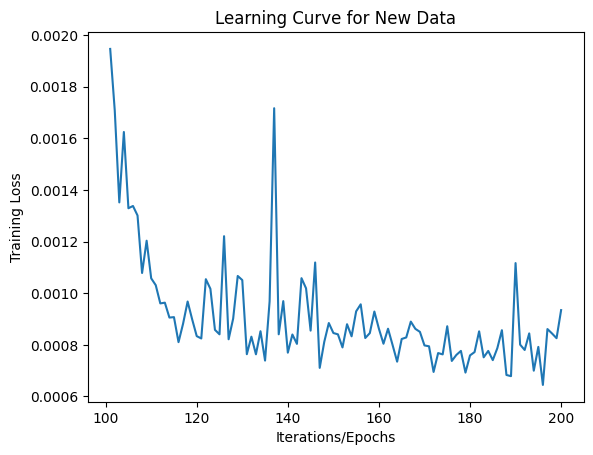

In [31]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\ActiveUpdates\Trial3\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")
plt.title("Learning Curve for New Data")
plt.xlabel("Iterations/Epochs")
plt.ylabel("Training Loss")

In [ ]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino",
    batchsize=16
)

In [19]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3")

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [73]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3"),
    frames_to_correct=list(range(2280, 5262)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 25/2982 frames
Corrected 50/2982 frames
Corrected 75/2982 frames
Corrected 100/2982 frames
Corrected 125/2982 frames
Corrected 150/2982 frames
Corrected 175/2982 frames
Corrected 200/2982 frames
Corrected 225/2982 frames
Corrected 250/2982 frames
Corrected 275/2982 frames
Corrected 300/2982 frames
Corrected 325/2982 frames
Corrected 350/2982 frames
Corrected 375/2982 frames
Corrected 400/2982 frames
Corrected 425/2982 frames
Corrected 450/2982 frames
Corrected 475/2982 frames
Corrected 500/2982 frames
Corrected 525/2982 frames
Corrected 550/2982 frames
Corrected 575/2982 frames
Corrected 600/2982 frames
Corrected 625/2982 frames
Corrected 650/2982 frames
Corrected 675/2982 frames
Corrected 700/2982 frames
Corrected 725/2982 frames
Corrected 750/2982 frames
Corrected 775/2982 frames
Corrected 800/2982 frames
Corrected 825/2982 frames
Corrected 850/2982 frames
Corrected 875/2982 frames
Corrected 900/2982 frames
Corrected 925/2982 frames
Corrected 950/2982 frames
Corrected 975/2

#### Trial 4: David Bowie


In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 5: David Bowie


In [ ]:
# predict_trial_from_jpg_stacks(
#     DavidBowie_Config,
#     "DavidBowie",
#     5,
#     base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
#     fps = 500,
#     batchsize = 16,
#     save_as_csv = True,
#     xma_base_name = "ModelUpdate",
#     snap_window_size = 4,
# )

In [ ]:
# train_update_model(bird = "DavidBowie", trial_num = 5)

In [ ]:
# _predict_with_updated_model(bird = "DavidBowie", trial_num = 5, frame_boundary = [2063, 4993], update_set = 'dino')

#### Trial 6: David Bowie


In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 7: David Bowie

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 8: David Bowie

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    8,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird = "DavidBowie", trial_num=8)

In [ ]:
_predict_with_updated_model(bird = "DavidBowie", trial_num=8, frame_boundary = [1812, 4699], update_set = 'dino')

#### Trial 9: David Bowie

n'existe pas

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    9,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 10: David Bowie

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    10,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 11: David Bowie

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    11,
    frame_range=[2063, 4993],
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird = "DavidBowie", trial_num=11, epochs=30, update_set="dino", nframes=10)

In [ ]:
## Must Remove the -best from the snapshots
_predict_with_updated_model(bird = "DavidBowie", trial_num=11, frame_boundary = [2063, 4993], update_set = 'dino')

In [1]:
# Can replace the above!
_Train_and_Predict(bird = "DavidBowie", trial_num=11, epochs=30, update_set="dino", nframes=10, frame_boundary = [2063, 4993])

NameError: name '_Train_and_Predict' is not defined

#### Trial 12

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    12,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird="DavidBowie", trial_num=12)

In [ ]:
_predict_with_updated_model(bird = "DavidBowie", trial_num=12)

In [78]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial12"),
    frames_to_correct=list(range(2495, 5320)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Cam mismatch: Cam1=5836, Cam2=6001
Corrected 25/2825 frames
Corrected 50/2825 frames
Corrected 75/2825 frames
Corrected 100/2825 frames
Corrected 125/2825 frames
Corrected 150/2825 frames
Corrected 175/2825 frames
Corrected 200/2825 frames
Corrected 225/2825 frames
Corrected 250/2825 frames
Corrected 275/2825 frames
Corrected 300/2825 frames
Corrected 325/2825 frames
Corrected 350/2825 frames
Corrected 375/2825 frames
Corrected 400/2825 frames
Corrected 425/2825 frames
Corrected 450/2825 frames
Corrected 475/2825 frames
Corrected 500/2825 frames
Corrected 525/2825 frames
Corrected 550/2825 frames
Corrected 575/2825 frames
Corrected 600/2825 frames
Corrected 625/2825 frames
Corrected 650/2825 frames
Corrected 675/2825 frames
Corrected 700/2825 frames
Corrected 725/2825 frames
Corrected 750/2825 frames
Corrected 775/2825 frames
Corrected 800/2825 frames
Corrected 825/2825 frames
Corrected 850/2825 frames
Corrected 875/2825 frames
Corrected 900/2825 frames
Corrected 925/2825 frames
Correc

#### Trial 13

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    13,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 14

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    14,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird="DavidBowie", trial_num=14)

In [ ]:
_predict_with_updated_model(bird = "DavidBowie", trial_num=14)

In [79]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial14"),
    frames_to_correct=list(range(2454, 5413)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 25/2959 frames
Corrected 50/2959 frames
Corrected 75/2959 frames
Corrected 100/2959 frames
Corrected 125/2959 frames
Corrected 150/2959 frames
Corrected 175/2959 frames
Corrected 200/2959 frames
Corrected 225/2959 frames
Corrected 250/2959 frames
Corrected 275/2959 frames
Corrected 300/2959 frames
Corrected 325/2959 frames
Corrected 350/2959 frames
Corrected 375/2959 frames
Corrected 400/2959 frames
Corrected 425/2959 frames
Corrected 450/2959 frames
Corrected 475/2959 frames
Corrected 500/2959 frames
Corrected 525/2959 frames
Corrected 550/2959 frames
Corrected 575/2959 frames
Corrected 600/2959 frames
Corrected 625/2959 frames
Corrected 650/2959 frames
Corrected 675/2959 frames
Corrected 700/2959 frames
Corrected 725/2959 frames
Corrected 750/2959 frames
Corrected 775/2959 frames
Corrected 800/2959 frames
Corrected 825/2959 frames
Corrected 850/2959 frames
Corrected 875/2959 frames
Corrected 900/2959 frames
Corrected 925/2959 frames
Corrected 950/2959 frames
Corrected 975/2

#### Trial 16

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    16,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [43]:
_predict_with_updated_model(
        bird = "DavidBowie",
        trial_num = 16,
        frame_boundary = [3470, 4953],
        batchsize = 16,
        update_set = 'dino'
    )

C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\active_updates\dino\ModelsToTune\Canari-FineTuner-2026-07-07\config.yaml
Cine Image Conversions Found
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\active_updates\dino\ModelsToTune\Canari-FineTuner-2026-07-07\dlc-models-pytorch\iteration-0\CanariJul7-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJul7shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\Cam2.avi
Video metadata: 
  Overall # of frames:    1484
  Duration of video [s]:  2.97
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 1484/1484 [00:40<00:00, 36.85it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\Updated\Cam2DLC_Resnet50_CanariJul7shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\Updated\Cam2DLC_Resnet50_CanariJul7shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\Cam1.avi
Video metadata: 
  Overall # of frames:    1170
  Duration of video [s]:  2.34
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 1170/1170 [00:31<00:00, 37.34it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\Updated\Cam1DLC_Resnet50_CanariJul7shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial16\Updated\Cam1DLC_Resnet50_CanariJul7shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial16/Updated/Cam1DLC_Resnet50_CanariJul7shuffle1_snapshot_200.csv')]


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_29012\707474332.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['364.1287', '364.49973', '364.7262', '364.88742', '364.65067', '364.9955', '364.69305', '365.1012', '365.10675', '365.38718', '365.37204', '365.5046', '365.62375', '365.7214', '365.84204', '365.81332', '366.14484', '366.30054', '366.4704', '366.63177', '366.5588', '366.8485', '366.9862', '366.75204', '366.85556', '366.7021', '367.35303', '367.38242', '367.53772', '367.4884', '367.67343', '368.05493', '368.15543', '367.80164', '368.19464', '368.36258', '368.36243', '368.5526', '368.40155', '368.53052', '368.12256', '368.036', '368.62726', '368.62717', '368.1409', '368.92563', '368.97318', '368.7371', '368.94492', '368.78876', '368.91653', '369.01013', '368.82553', '368.82968', '369.52826', '369.0977', '369.55408', '369.17014', '369.15088', '369.2432', '369.3047', '369.54037', '369.24

Corrected 250/1483 frames
Corrected 500/1483 frames
Corrected 750/1483 frames
Corrected 1000/1483 frames
Corrected 1250/1483 frames
Corrected 1483/1483 frames
Done 1483 frames in 55.7s


{'config': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial16/active_updates/dino/ModelsToTune/Canari-FineTuner-2026-07-07/config.yaml'),
 'update_set': 'dino',
 'Updated Csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial16/Updated_Predictions.csv'),
 'output_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial16/Updated')}

#### Trial 18

In [175]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    18,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
    frame_range = [2477, 5438]
)

Cine Image Conversions Found
Now To Analyze the videos with existing model!
[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18/Cam1DLC_Resnet50_CanariMay22shuffle1_snapshot_200.csv')]
Converting predictions to XMA format


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_4540\707474332.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['403.97455', '403.57895', '403.71854', '403.46887', '403.32468', '402.61005', '402.10727', '401.34293', '400.39056', '399.3735', '396.74783', '395.8261', '394.63275', '394.05038', '392.86554', '393.18918', '392.04385', '391.7828', '390.68857', '390.602', '387.98767', '387.56818', '387.40796', '387.20877', '386.5626', '386.47812', '386.08298', '385.67978', '385.75375', '385.51862', '385.43185', '385.5901', '384.8781', '385.2401', '384.84457', '385.2153', '385.1826', '384.99698', '384.48547', '384.14807', '384.27405', '383.9981', '384.5257', '384.1741', '384.63083', '384.4671', '384.03842', '384.19937', '384.13132', '384.46863', '384.07312', '384.00674', '383.9738', '383.96518', '384.19437', '383.6283', '383.93286', '383.13016', '383.62573', '383.82394', '383.88736', '383.55405', '383.

Corrected 250/2961 frames
Corrected 500/2961 frames
Corrected 750/2961 frames
Corrected 1000/2961 frames
Corrected 1250/2961 frames
Corrected 1500/2961 frames
Corrected 1750/2961 frames
Corrected 2000/2961 frames
Corrected 2250/2961 frames
Corrected 2500/2961 frames
Corrected 2750/2961 frames
Corrected 2961/2961 frames
Done 2961 frames in 107.0s
Finished full pipeline for DavidBowie Trial18 -> C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial18


{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18/Cam1DLC_Resnet50_CanariMay22shuffle1_snapshot_200.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18/Cam2DLC_Resnet50_CanariMay22shuffle1_snapshot_200.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/DavidBowie/Trial18/ModelUpdate-Predicted2DPoints.csv')}

# Tulio Training First Model

Selected data from dino method first from the whole set to train first model (chose 100 frames)

In [ ]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\active_updates\dino"
)

models = src_trial / "Model"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Tulio",
    experimenter="Tyler",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"Tulio": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\active_updates\dino\data\LabeledBodyPartsCoordinates.csv"
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="TulioDiverseData300",
    experimenter="Tyler",
    nframes=300,
    frame_selection_seed=42,
)

In [ ]:
import time

t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
)
elapsed = time.perf_counter() - t0
print(elapsed)

In [ ]:
config_path_tulio = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml"

#### Trial 1: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    1,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
# # Make sure you have updated your data first
# train_update_model(
#     bird= 'Tulio',
#     trial_num = 1
#     )

In [ ]:
# # Run after the above frame
# _predict_with_updated_model("Tulio", 1)

#### Trial 3: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    3,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(
    bird= 'Tulio',
    trial_num = 3
    )

In [ ]:
_predict_with_updated_model("Tulio", 5)

In [ ]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3"),
    frames_to_correct=list(range(2565, 5524)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

#### Trial 4: Tulio


In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    4,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 5: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    5,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(
    bird= 'Tulio',
    trial_num = 5
    )

In [ ]:
_predict_with_updated_model("Tulio", 5)

In [25]:
pred_df_5 = pd.read_csv(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\ModelUpdateMonday-Predicted2DPoints.csv"))

In [26]:
df_out = correct_frames_from_df_fast(
    pred_df= pred_df_5,
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5"),
    frames_to_correct=list(range(2375, 5350)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 250/2975 frames
Corrected 500/2975 frames
Corrected 750/2975 frames
Corrected 1000/2975 frames
Corrected 1250/2975 frames
Corrected 1500/2975 frames
Corrected 1750/2975 frames
Corrected 2000/2975 frames
Corrected 2250/2975 frames
Corrected 2500/2975 frames
Corrected 2750/2975 frames
Corrected 2975/2975 frames
Done 2975 frames in 104.3s


In [28]:
df_out.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\df_corrected.csv", index=False)

In [29]:
pred_df_updated_5 = pd.read_csv(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\df_corrected.csv"))

In [30]:
pred_df_updated_5

,CraniumRightPosterior_cam1_X,CraniumRightPosterior_cam1_Y,CraniumRightPosterior_cam2_X,CraniumRightPosterior_cam2_Y,CraniumLeftPosterior_cam1_X,CraniumLeftPosterior_cam1_Y,CraniumLeftPosterior_cam2_X,CraniumLeftPosterior_cam2_Y,CraniumRightMiddle_cam1_X,CraniumRightMiddle_cam1_Y,...,PelvisPosterior_cam2_X,PelvisPosterior_cam2_Y,PelvisAnterior_cam1_X,PelvisAnterior_cam1_Y,PelvisAnterior_cam2_X,PelvisAnterior_cam2_Y,PelvisRightMiddle_cam1_X,PelvisRightMiddle_cam1_Y,PelvisRightMiddle_cam2_X,PelvisRightMiddle_cam2_Y
0,266.133970,470.096400,293.52774,430.002530,269.991400,438.738040,306.69864,400.457900,266.125950,475.383880,...,554.812870,428.590580,557.461700,447.802550,513.830700,419.336700,586.88513,439.573270,415.93234,659.260250
1,266.097750,470.481700,292.54920,430.108030,270.703200,438.597700,306.58330,400.504640,266.409360,475.763850,...,555.350340,428.468930,557.052100,448.627750,513.837460,419.103100,584.78894,439.078300,537.49150,422.694700
2,266.593170,470.740000,291.13850,431.188050,275.391480,439.668150,305.51483,401.169040,266.718200,475.976170,...,553.898440,429.815770,556.942900,449.235800,515.601200,419.112370,584.54800,441.005550,521.99140,417.629670
3,266.890560,470.659200,291.32227,432.512540,275.264650,439.862100,305.69336,399.315300,267.099430,476.202100,...,555.570740,427.770660,555.974100,449.619080,515.488900,421.426480,584.36360,439.371430,522.27435,418.790440
4,267.078300,470.549800,290.17667,432.404140,275.627660,440.132840,303.08447,401.517600,267.235960,476.482480,...,557.418950,429.947900,556.679300,450.664100,515.184630,421.893100,583.54486,441.768980,547.68134,423.890080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5994,716.529360,18.240510,756.03250,26.519653,132.415790,30.393557,99.97098,30.251127,68.716896,18.106968,...,42.567894,11.602678,166.483610,18.641438,60.780968,4.444103,167.06865,19.023571,747.92860,25.633564
5995,756.267150,26.669548,756.03250,26.519653,116.121796,30.474087,99.97098,30.251127,132.939160,17.867111,...,42.567894,11.602678,60.789925,4.385548,60.780968,4.444103,494.07712,20.329742,747.92860,25.633564
5996,716.473500,18.241085,756.03250,26.519653,356.373140,30.429121,99.97098,30.251127,180.930970,17.829624,...,42.567894,11.602678,60.730263,4.357191,60.780968,4.444103,334.03662,20.049107,747.92860,25.633564
5997,716.522300,18.392693,756.03250,26.519653,644.284000,31.156220,99.97098,30.251127,85.110700,18.159462,...,42.567894,11.602678,60.689780,4.305025,60.780968,4.444103,756.40640,26.666267,747.92860,25.633564


#### Trial 6: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    6,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 7: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    7,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [83]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7"),
    frames_to_correct=list(range(4000, 4200)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 25/200 frames
Corrected 50/200 frames
Corrected 75/200 frames
Corrected 100/200 frames
Corrected 125/200 frames
Corrected 150/200 frames
Corrected 175/200 frames
Corrected 200/200 frames
Saved: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\df_corrected.csv
Done 200 frames in 48.5s


#### Trial 8: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    8,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(
    bird= 'Tulio',
    trial_num = 8
    )

## Must Remove the -best from the snapshots
_predict_with_updated_model(
    bird="Tulio",
    trial_num = 8
    )

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 9: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    combined_config,
    "Tulio",
    9,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:

trial9_unified = unify_active_update_sets(
    source_root=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\active_updates\Trial9"),
    update_names=("dino", "displacement"),
    unified_name="unified",
    overwrite=True,
)


In [ ]:
train_update_model(
    bird='Tulio',
    trial_num=9,
    update_set='unified',
)

In [ ]:
## Must Remove the -best from the snapshots
_predict_with_updated_model(
    bird="Tulio",
    trial_num=9,
    update_set="unified",
)

In [65]:
import cv2
import time

# ------------------------------------------------------------------
# Inputs
# ------------------------------------------------------------------
pred_csv = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\ModelUpdateMonday-Predicted2DPoints.csv"
)
out_csv = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\df_corrected.csv"
)

cam_dirs = {
    "cam1": Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\Cam1"),
    "cam2": Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\Cam2"),
}

# Choose either a contiguous range OR an explicit list.
# Example contiguous range (inclusive):
start_frame = 2581
end_frame = 5381
frames_to_correct = list(range(start_frame, end_frame + 1))

# Example explicit list:
# frames_to_correct = [5549, 5550, 5602]

max_match_dist = 15.0

# ------------------------------------------------------------------
# Load data and image indexes
# ------------------------------------------------------------------
df = pd.read_csv(pred_csv)
df_corrected = df.copy(deep=True)

image_paths = {
    camera: collect_images(folder)
    for camera, folder in cam_dirs.items()
}

if len(image_paths["cam1"]) != len(image_paths["cam2"]):
    raise ValueError(
        f"Cam image count mismatch: cam1={len(image_paths['cam1'])}, cam2={len(image_paths['cam2'])}"
    )

# Keep only valid frame indices
valid_frames = [
    i for i in sorted(set(int(x) for x in frames_to_correct))
    if 0 <= i < len(df_corrected) and i < len(image_paths["cam1"]) and i < len(image_paths["cam2"])
]

if not valid_frames:
    raise ValueError("No valid frames to correct after bounds checking.")

# ------------------------------------------------------------------
# Correct selected frames (camera-correct image source)
# ------------------------------------------------------------------
t0 = time.perf_counter()

for n, frame_idx in enumerate(valid_frames, start=1):
    row = df_corrected.iloc[frame_idx]

    for camera in ("cam1", "cam2"):
        image_path = image_paths[camera][frame_idx]

        # cv2 grayscale read is typically faster than skimage.io.imread for this loop.
        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue

        updates = _correct_camera_frame(
            image=gray,
            row=row,
            camera=camera,
            max_match_dist=max_match_dist,
        )

        if updates:
            df_corrected.loc[df_corrected.index[frame_idx], list(updates.keys())] = list(updates.values())

    if n % 25 == 0 or n == len(valid_frames):
        print(f"Corrected {n}/{len(valid_frames)} frames")

elapsed = time.perf_counter() - t0

df_corrected.to_csv(out_csv, index=False)
print(f"Saved corrected CSV: {out_csv}")
print(f"Finished correcting {len(valid_frames)} selected frames in {elapsed:.1f}s")

Corrected 25/2801 frames
Corrected 50/2801 frames
Corrected 75/2801 frames
Corrected 100/2801 frames
Corrected 125/2801 frames
Corrected 150/2801 frames
Corrected 175/2801 frames
Corrected 200/2801 frames
Corrected 225/2801 frames
Corrected 250/2801 frames
Corrected 275/2801 frames
Corrected 300/2801 frames
Corrected 325/2801 frames
Corrected 350/2801 frames
Corrected 375/2801 frames
Corrected 400/2801 frames
Corrected 425/2801 frames
Corrected 450/2801 frames
Corrected 475/2801 frames
Corrected 500/2801 frames
Corrected 525/2801 frames
Corrected 550/2801 frames
Corrected 575/2801 frames
Corrected 600/2801 frames
Corrected 625/2801 frames
Corrected 650/2801 frames
Corrected 675/2801 frames
Corrected 700/2801 frames
Corrected 725/2801 frames
Corrected 750/2801 frames
Corrected 775/2801 frames
Corrected 800/2801 frames
Corrected 825/2801 frames
Corrected 850/2801 frames
Corrected 875/2801 frames
Corrected 900/2801 frames
Corrected 925/2801 frames
Corrected 950/2801 frames
Corrected 975/2

In [ ]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8"),
    frames_to_correct=list(range(1812, 4675)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

#### Trial 10: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    combined_config,
    "Tulio",
    10,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500, 
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 11: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    11,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 12: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    12,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)